# PINNsFormer + AutoBalance-4：Navier–Stokes × 3 Seeds

本 notebook **只运行 AutoBalance-4**，不包含 Adam / ConFIG / M-ConFIG 等 baseline。

四个 optimization objectives 保持为：

$$
L_{u,\mathrm{data}},\quad L_{v,\mathrm{data}},\quad L_{f_u},\quad L_{f_v}.
$$

方法依据 **AutoBalance: An Automatic Balancing Framework for Training Physics-Informed Neural Networks**（arXiv:2510.06684）。论文 Algorithm 1 的核心是：每个 loss 独立维护 adaptive optimizer state，先得到 task-specific preconditioned direction，再做 post-combine：

$$
m_i^k=\beta_1m_i^{k-1}+(1-\beta_1)g_i^k,
$$

$$
v_i^k=\beta_2v_i^{k-1}+(1-\beta_2)(g_i^k)^2,
$$

$$
d_i^k=\frac{\hat m_i^k}{\sqrt{\hat v_i^k}+\epsilon},\qquad
\tilde d^k=\frac{1}{4}\sum_{i=1}^{4}d_i^k,
$$

$$
w_k=(1-\eta_k\gamma)w_{k-1}-\eta_k\tilde d^k.
$$

当前实验适配保持既有 PINNsFormer Navier–Stokes 设置：800 个训练点、pseudo sequence=5、1000 steps、seed=0/1/2。默认 `LR=1e-4`，`WEIGHT_DECAY=0`，用于先隔离 **private preconditioning + post-combine** 本身；这不是声称论文原实验使用相同超参数。


# ⭐⭐⭐ 核心方法：AutoBalance-4 / Post-Combine

```text
u_data -> g_u  -> private Adam state_u  -> d_u
v_data -> g_v  -> private Adam state_v  -> d_v
f_u    -> g_fu -> private Adam state_fu -> d_fu
f_v    -> g_fv -> private Adam state_fv -> d_fv
                                         ↓
                    d_bar = mean(d_u,d_v,d_fu,d_fv)
                                         ↓
                         one shared parameter update
```

仍然只有 **一个 PINNsFormer**。四个 loss 只是分别维护自己的 `(m_i,v_i)`。本实现不会创建四个 optimizer 然后依次 `step()`，因为那会让后一个 loss 在已经改变的参数位置上更新，破坏论文的 post-combine 语义。


In [1]:
from pathlib import Path
import csv, gc, json, math, os, random, sys, time
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

PINNSFORMER_ROOT = Path(os.environ.get('PINNSFORMER_ROOT','/home/simplexity/cyt/pinnsformer-main'))
EXPERIMENT_ROOT = Path(os.environ.get('PINNSFORMER_CONFIG_ROOT', str(PINNSFORMER_ROOT/'pinnsformer-config')))
DATA_PATH = PINNSFORMER_ROOT/'demo'/'navier_stokes'/'cylinder_nektar_wake.mat'
OUTPUT_ROOT = EXPERIMENT_ROOT/'outputs'/'navier_stokes_autobalance4'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(EXPERIMENT_ROOT))

METHOD_KEY='autobalance4'
METHOD_NAME='PINNsFormer / AutoBalance-4'
RUN_SEEDS=[0,1,2]
FORCE_RERUN=False
DEVICE='cuda:0' if torch.cuda.is_available() else 'cpu'
N_TRAIN=800
NUM_STEP=5
TIME_STEP=1e-2
EPOCHS=1000
SNAPSHOT=100
LR=1e-4
WEIGHT_DECAY=0.0
BETA1=0.9
BETA2=0.999
EPS=1e-8
METRIC_INTERVAL=10
LOSS_KEYS=['u_data','v_data','f_u','f_v']
LOSS_WEIGHTS={k:1.0 for k in LOSS_KEYS}
PHYSICS_THRESHOLDS=[1e-2,5e-3,2e-3,1e-3,5e-4]

assert DATA_PATH.exists(), DATA_PATH
print('DATA_PATH:', DATA_PATH)
print('OUTPUT_ROOT:', OUTPUT_ROOT)
print('DEVICE:', DEVICE)
print('RUN_SEEDS:', RUN_SEEDS)
print('LR / weight_decay:', LR, WEIGHT_DECAY)


DATA_PATH: /home/simplexity/cyt/pinnsformer-main/demo/navier_stokes/cylinder_nektar_wake.mat
OUTPUT_ROOT: /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_autobalance4
DEVICE: cuda:0
RUN_SEEDS: [0, 1, 2]
LR / weight_decay: 0.0001 0.0


/home/simplexity/anaconda3/envs/config_pinn/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from navier_stokes_common import (
    PINNsformer, init_weights, get_n_params, load_training_data,
    compute_ns_losses, evaluation_tensors,
)
from gradient_diagnostics import gradient_vector, cosine_similarity

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

def sync_cuda():
    if torch.cuda.is_available(): torch.cuda.synchronize()

def make_model(device):
    model=PINNsformer(d_out=2,d_hidden=512,d_model=32,N=1,heads=2).to(device)
    model.apply(init_weights)
    return model

def write_rows(path, rows):
    path=Path(path); path.parent.mkdir(parents=True,exist_ok=True)
    if not rows: return
    with path.open('w',newline='',encoding='utf-8') as f:
        w=csv.DictWriter(f,fieldnames=list(rows[0].keys())); w.writeheader(); w.writerows(rows)

def read_rows(path):
    with Path(path).open('r',newline='',encoding='utf-8') as f: return list(csv.DictReader(f))

def safe_mean(xs):
    a=np.asarray(xs,dtype=float); a=a[np.isfinite(a)]
    return float(a.mean()) if len(a) else float('nan')

def safe_std(xs):
    a=np.asarray(xs,dtype=float); a=a[np.isfinite(a)]
    if len(a)>1: return float(a.std(ddof=1))
    if len(a)==1: return 0.0
    return float('nan')

def rel_l2(pred,true):
    pred=np.asarray(pred).reshape(-1); true=np.asarray(true).reshape(-1)
    return float(np.linalg.norm(pred-true)/np.linalg.norm(true))

def cv(xs,eps=1e-12):
    a=np.asarray(xs,dtype=float); m=float(a.mean())
    return float(a.std()/abs(m)) if abs(m)>eps else float('nan')


# ⭐⭐⭐ AutoBalance 核心算子

下面严格按论文 Algorithm 1 的结构维护每个 loss 的独立一阶、二阶矩。`combined_direction` 使用四个 task-specific directions 的**算术平均**，不是求和。


In [3]:
class AutoBalanceAdamW:
    def __init__(self, task_names, num_parameters, device, beta1=0.9, beta2=0.999, eps=1e-8):
        self.task_names=list(task_names); self.n=int(num_parameters); self.device=torch.device(device)
        self.beta1=float(beta1); self.beta2=float(beta2); self.eps=float(eps); self.t=0
        self.m={k:torch.zeros(self.n,device=self.device) for k in self.task_names}
        self.v={k:torch.zeros(self.n,device=self.device) for k in self.task_names}

    @torch.no_grad()
    def calculate_direction(self, gradients):
        self.t += 1
        ds={}
        for k in self.task_names:
            g=gradients[k].detach()
            self.m[k].mul_(self.beta1).add_(g,alpha=1-self.beta1)
            self.v[k].mul_(self.beta2).addcmul_(g,g,value=1-self.beta2)
            mhat=self.m[k]/(1-self.beta1**self.t)
            vhat=self.v[k]/(1-self.beta2**self.t)
            ds[k]=mhat/(torch.sqrt(vhat)+self.eps)
        dbar=torch.stack([ds[k] for k in self.task_names],dim=0).mean(dim=0)
        return dbar, ds

@torch.no_grad()
def apply_update(model, direction, lr, weight_decay=0.0):
    params=[p for p in model.parameters() if p.requires_grad]
    off=0; decay=1-lr*weight_decay
    for p in params:
        n=p.numel(); d=direction[off:off+n].view_as(p)
        if weight_decay!=0.0: p.mul_(decay)
        p.add_(d,alpha=-lr); off += n
    assert off==direction.numel()

def compute_four_gradients(model,batch):
    losses=compute_ns_losses(model,batch['x'],batch['y'],batch['t'],batch['u'],batch['v'])
    grads={}
    for i,k in enumerate(LOSS_KEYS):
        grads[k]=gradient_vector(LOSS_WEIGHTS[k]*losses[k], model, retain_graph=(i<len(LOSS_KEYS)-1))
    return losses, grads


# 机制诊断

本轮不再比较 baseline，但会保存 AutoBalance 自己最关键的内部证据：

- raw gradient norm / cosine；
- task-specific preconditioned update norm / cosine；
- 最终 `d_bar` 与四个 raw gradients 的 alignment；
- `raw_grad_norm_cv` 与 `precond_update_norm_cv`。

这样可以直接检查论文所强调的 implicit balancing 是否在当前四 loss 上出现。


In [4]:
PAIRS=[('u_data','v_data'),('u_data','f_u'),('u_data','f_v'),('v_data','f_u'),('v_data','f_v'),('f_u','f_v')]

def geometry_metrics(grads,dirs,dbar):
    row={}; raw_cos=[]; dir_cos=[]
    raw_norms={k:float(grads[k].norm()) for k in LOSS_KEYS}
    dir_norms={k:float(dirs[k].norm()) for k in LOSS_KEYS}
    for a,b in PAIRS:
        x=cosine_similarity(grads[a],grads[b]); y=cosine_similarity(dirs[a],dirs[b])
        row[f'raw_cos_{a}__{b}']=x; row[f'precond_cos_{a}__{b}']=y
        if np.isfinite(x): raw_cos.append(x)
        if np.isfinite(y): dir_cos.append(y)
    aligns=[]
    for k in LOSS_KEYS:
        row[f'raw_grad_norm_{k}']=raw_norms[k]
        row[f'precond_update_norm_{k}']=dir_norms[k]
        z=cosine_similarity(dbar,grads[k]); row[f'combined_vs_raw_cos_{k}']=z
        if np.isfinite(z): aligns.append(z)
    row['mean_raw_pair_cosine']=float(np.mean(raw_cos))
    row['raw_pair_conflict_rate']=float(np.mean(np.asarray(raw_cos)<0))
    row['mean_precond_pair_cosine']=float(np.mean(dir_cos))
    row['precond_pair_conflict_rate']=float(np.mean(np.asarray(dir_cos)<0))
    row['min_combined_vs_raw_alignment']=float(np.min(aligns))
    row['combined_nonpositive_alignment_rate']=float(np.mean(np.asarray(aligns)<=0))
    row['raw_grad_norm_cv']=cv(list(raw_norms.values()))
    row['precond_update_norm_cv']=cv(list(dir_norms.values()))
    row['combined_direction_norm']=float(dbar.norm())
    return row


# Smoke test


In [5]:
device=torch.device(DEVICE)
set_seed(123)
smoke_batch,_=load_training_data(DATA_PATH,device,seed=123,n_train=32,num_step=NUM_STEP,time_step=TIME_STEP)
smoke_model=make_model(device)
losses,grads=compute_four_gradients(smoke_model,smoke_batch)
op=AutoBalanceAdamW(LOSS_KEYS,get_n_params(smoke_model),device,BETA1,BETA2,EPS)
dbar,dirs=op.calculate_direction(grads)
assert torch.isfinite(dbar).all() and dbar.numel()==get_n_params(smoke_model)
before=torch.cat([p.detach().reshape(-1) for p in smoke_model.parameters() if p.requires_grad])
apply_update(smoke_model,dbar,LR,WEIGHT_DECAY)
after=torch.cat([p.detach().reshape(-1) for p in smoke_model.parameters() if p.requires_grad])
print('smoke loss:', {k:float(losses[k].detach()) for k in LOSS_KEYS})
print('parameter delta norm:', float((after-before).norm()))
assert float((after-before).norm())>0

del smoke_batch,smoke_model,losses,grads,dbar,dirs,op,before,after
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
print('Smoke test passed.')


smoke loss: {'u_data': 0.8734605312347412, 'v_data': 0.19829295575618744, 'f_u': 0.09273136407136917, 'f_v': 0.04754483699798584}
parameter delta norm: 0.03874250873923302
Smoke test passed.


# Field evaluation / threshold


In [6]:
def evaluate_field(model,reference,device):
    ev,truth=evaluation_tensors(reference,device,snap=SNAPSHOT,num_step=NUM_STEP,time_step=TIME_STEP)
    out=model(ev['x'],ev['y'],ev['t']); psi=out[:,:,0:1]; pseq=out[:,:,1:2]
    useq=torch.autograd.grad(psi,ev['y'],torch.ones_like(psi),retain_graph=True)[0]
    vseq=-torch.autograd.grad(psi,ev['x'],torch.ones_like(psi))[0]
    up=useq[:,0,0].detach().cpu().numpy(); vp=vseq[:,0,0].detach().cpu().numpy(); pp=pseq[:,0,0].detach().cpu().numpy()
    ut=np.asarray(truth['u']).reshape(-1); vt=np.asarray(truth['v']).reshape(-1); pt=np.asarray(truth['p']).reshape(-1)
    pa=pp-pp.mean()+pt.mean()
    metrics={'u_relative_l2':rel_l2(up,ut),'v_relative_l2':rel_l2(vp,vt),'p_raw_relative_l2':rel_l2(pp,pt),'p_mean_aligned_relative_l2':rel_l2(pa,pt)}
    preds={'u_pred':up,'v_pred':vp,'p_pred':pp,'p_aligned':pa,'u_true':ut,'v_true':vt,'p_true':pt}
    return metrics,preds

def threshold_rows(seed,history):
    rows=[]
    for th in PHYSICS_THRESHOLDS:
        hits=[r for r in history if float(r['physics'])<=th]
        if hits:
            h=hits[0]; rows.append({'seed':seed,'method':METHOD_NAME,'threshold':th,'crossed':1,'step':h['step'],'algorithm_elapsed_s':h['algorithm_elapsed_s']})
        else:
            rows.append({'seed':seed,'method':METHOD_NAME,'threshold':th,'crossed':0,'step':np.nan,'algorithm_elapsed_s':np.nan})
    return rows


# ⭐⭐⭐ 正式训练：只运行 AutoBalance-4


In [7]:
def train_seed(seed,batch,outdir,device):
    set_seed(seed); model=make_model(device); nparams=get_n_params(model)
    op=AutoBalanceAdamW(LOSS_KEYS,nparams,device,BETA1,BETA2,EPS)
    history=[]
    if torch.cuda.is_available():
        torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats(device)
    sync_cuda(); start=time.perf_counter()
    for step in tqdm(range(EPOCHS),desc=f'AutoBalance-4 seed={seed}'):
        losses,grads=compute_four_gradients(model,batch)
        dbar,dirs=op.calculate_direction(grads)
        if step%METRIC_INTERVAL==0 or step==EPOCHS-1:
            row={'seed':seed,'method':METHOD_NAME,'step':step,'algorithm_elapsed_s':time.perf_counter()-start,'lr':LR,
                 'total':float(losses['total'].detach()),'data':float(losses['data'].detach()),'physics':float(losses['physics'].detach()),
                 'u_data':float(losses['u_data'].detach()),'v_data':float(losses['v_data'].detach()),'f_u':float(losses['f_u'].detach()),'f_v':float(losses['f_v'].detach())}
            row.update(geometry_metrics(grads,dirs,dbar)); history.append(row)
        apply_update(model,dbar,LR,WEIGHT_DECAY)
        del losses,grads,dbar,dirs
    sync_cuda(); wall=time.perf_counter()-start
    peak=torch.cuda.max_memory_allocated(device)/1024**2 if torch.cuda.is_available() else float('nan')
    outdir=Path(outdir); outdir.mkdir(parents=True,exist_ok=True)
    torch.save(model.state_dict(),outdir/'model.pt'); write_rows(outdir/'metric_history.csv',history)
    meta={'seed':seed,'method':METHOD_NAME,'method_key':METHOD_KEY,'paper_arxiv':'2510.06684','num_objectives':4,
          'epochs':EPOCHS,'lr':LR,'weight_decay':WEIGHT_DECAY,'beta1':BETA1,'beta2':BETA2,'eps':EPS,
          'n_train':N_TRAIN,'num_step':NUM_STEP,'time_step':TIME_STEP,'snapshot':SNAPSHOT,'model_params':nparams,
          'fresh_task_gradients_per_step':4,'true_task_gradient_evaluations':4*EPOCHS,
          'algorithm_wall_time_s':wall,'algorithm_wall_time_min':wall/60,'max_core_peak_vram_mib':peak,
          'implementation_note':'Algorithm-1-style private Adam moments per loss, arithmetic mean post-combine; weight_decay=0 is project adaptation.'}
    (outdir/'run_meta.json').write_text(json.dumps(meta,ensure_ascii=False,indent=2),encoding='utf-8')
    print(f'seed={seed} wall={wall/60:.3f} min peak={peak:.2f} MiB')
    return model,history,meta


# 运行 3 seeds


In [8]:
for seed in RUN_SEEDS:
    outdir=OUTPUT_ROOT/f'seed_{seed}'/METHOD_KEY
    required=[outdir/'model.pt',outdir/'metric_history.csv',outdir/'run_meta.json',outdir/'field_metrics.csv',outdir/'threshold_steps.csv',outdir/'predictions.npz']
    if all(p.exists() for p in required) and not FORCE_RERUN:
        print('[reuse]',seed); continue
    batch,reference=load_training_data(DATA_PATH,device,seed=seed,n_train=N_TRAIN,num_step=NUM_STEP,time_step=TIME_STEP)
    model,history,meta=train_seed(seed,batch,outdir,device)
    fm,preds=evaluate_field(model,reference,device); last=history[-1]
    row={'seed':seed,'method':METHOD_NAME,**fm,'final_total_loss':last['total'],'final_data_loss':last['data'],'final_physics_loss':last['physics'],
         'mean_sampled_total_loss':safe_mean([r['total'] for r in history]),'mean_sampled_data_loss':safe_mean([r['data'] for r in history]),
         'mean_sampled_physics_loss':safe_mean([r['physics'] for r in history]),'algorithm_wall_time_min':meta['algorithm_wall_time_min'],
         'max_core_peak_vram_mib':meta['max_core_peak_vram_mib'],'true_task_gradient_evaluations':meta['true_task_gradient_evaluations'],
         'mean_min_combined_vs_raw_alignment':safe_mean([r['min_combined_vs_raw_alignment'] for r in history]),
         'mean_combined_nonpositive_alignment_rate':safe_mean([r['combined_nonpositive_alignment_rate'] for r in history]),
         'mean_raw_grad_norm_cv':safe_mean([r['raw_grad_norm_cv'] for r in history]),
         'mean_precond_update_norm_cv':safe_mean([r['precond_update_norm_cv'] for r in history])}
    write_rows(outdir/'field_metrics.csv',[row]); write_rows(outdir/'threshold_steps.csv',threshold_rows(seed,history)); np.savez(outdir/'predictions.npz',**preds)
    print('field:',fm)
    del batch,reference,model,history,preds
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
print('AutoBalance-4 finished or reused.')


AutoBalance-4 seed=0: 100%|██████████| 1000/1000 [10:41<00:00,  1.56it/s]


seed=0 wall=10.688 min peak=8411.46 MiB
field: {'u_relative_l2': 0.06784217496690607, 'v_relative_l2': 0.22114084824154676, 'p_raw_relative_l2': 1.6084682552147556, 'p_mean_aligned_relative_l2': 0.3788920386727252}


AutoBalance-4 seed=1: 100%|██████████| 1000/1000 [10:47<00:00,  1.54it/s]


seed=1 wall=10.796 min peak=8411.46 MiB
field: {'u_relative_l2': 0.06857594243615056, 'v_relative_l2': 0.18166626147089307, 'p_raw_relative_l2': 9.624131886264792, 'p_mean_aligned_relative_l2': 0.3550848596984857}


AutoBalance-4 seed=2: 100%|██████████| 1000/1000 [10:48<00:00,  1.54it/s]


seed=2 wall=10.815 min peak=8411.46 MiB
field: {'u_relative_l2': 0.07118272350357611, 'v_relative_l2': 0.16505670111408843, 'p_raw_relative_l2': 7.674929301376444, 'p_mean_aligned_relative_l2': 0.36765032788437274}
AutoBalance-4 finished or reused.


# 聚合 3 seeds


In [9]:
AGG=OUTPUT_ROOT/'aggregate'; AGG.mkdir(parents=True,exist_ok=True)
fields=[]; histories=[]; thresholds=[]; metas=[]
for seed in RUN_SEEDS:
    d=OUTPUT_ROOT/f'seed_{seed}'/METHOD_KEY
    if not (d/'field_metrics.csv').exists(): continue
    fields += read_rows(d/'field_metrics.csv'); histories += read_rows(d/'metric_history.csv'); thresholds += read_rows(d/'threshold_steps.csv')
    metas.append(json.loads((d/'run_meta.json').read_text(encoding='utf-8')))
write_rows(AGG/'all_field_metrics.csv',fields); write_rows(AGG/'all_metric_history.csv',histories); write_rows(AGG/'all_threshold_steps.csv',thresholds); write_rows(AGG/'all_run_meta.csv',metas)

metrics=['u_relative_l2','v_relative_l2','p_raw_relative_l2','p_mean_aligned_relative_l2','final_total_loss','final_data_loss','final_physics_loss',
         'mean_sampled_total_loss','mean_sampled_data_loss','mean_sampled_physics_loss','algorithm_wall_time_min','max_core_peak_vram_mib',
         'true_task_gradient_evaluations','mean_min_combined_vs_raw_alignment','mean_combined_nonpositive_alignment_rate','mean_raw_grad_norm_cv','mean_precond_update_norm_cv']
summary=[]
for m in metrics:
    vals=[float(r[m]) for r in fields]; summary.append({'method':METHOD_NAME,'metric':m,'n':len(vals),'mean':safe_mean(vals),'std':safe_std(vals)})
write_rows(AGG/'mean_std_summary.csv',summary)
for r in summary: print(r)

ths=[]
for th in PHYSICS_THRESHOLDS:
    rs=[r for r in thresholds if math.isclose(float(r['threshold']),th,abs_tol=1e-15)]; hit=[r for r in rs if int(r['crossed'])==1]
    ths.append({'method':METHOD_NAME,'threshold':th,'n_seed_total':len(rs),'n_crossed':len(hit),
                'mean_step':safe_mean([float(r['step']) for r in hit]),'std_step':safe_std([float(r['step']) for r in hit]),
                'mean_algorithm_time_s':safe_mean([float(r['algorithm_elapsed_s']) for r in hit]),'std_algorithm_time_s':safe_std([float(r['algorithm_elapsed_s']) for r in hit])})
write_rows(AGG/'threshold_mean_std.csv',ths)


{'method': 'PINNsFormer / AutoBalance-4', 'metric': 'u_relative_l2', 'n': 3, 'mean': 0.06920028030221093, 'std': 0.0017556094268685407}
{'method': 'PINNsFormer / AutoBalance-4', 'metric': 'v_relative_l2', 'n': 3, 'mean': 0.18928793694217608, 'std': 0.028808424852736495}
{'method': 'PINNsFormer / AutoBalance-4', 'metric': 'p_raw_relative_l2', 'n': 3, 'mean': 6.30250981428533, 'std': 4.18035492487721}
{'method': 'PINNsFormer / AutoBalance-4', 'metric': 'p_mean_aligned_relative_l2', 'n': 3, 'mean': 0.36720907541852793, 'std': 0.011909721679444426}
{'method': 'PINNsFormer / AutoBalance-4', 'metric': 'final_total_loss', 'n': 3, 'mean': 0.004970362720390161, 'std': 0.0004661345759634261}
{'method': 'PINNsFormer / AutoBalance-4', 'metric': 'final_data_loss', 'n': 3, 'mean': 0.004433260144044955, 'std': 0.0004752543365646275}
{'method': 'PINNsFormer / AutoBalance-4', 'metric': 'final_physics_loss', 'n': 3, 'mean': 0.0005371024017222226, 'std': 3.104543632029922e-05}
{'method': 'PINNsFormer / A

# AutoBalance 特有机制汇总


In [10]:
task_rows=[]
for k in LOSS_KEYS:
    task_rows.append({'task':k,'n_logged_steps':len(histories),
      'mean_raw_grad_norm':safe_mean([float(r[f'raw_grad_norm_{k}']) for r in histories]),
      'std_raw_grad_norm':safe_std([float(r[f'raw_grad_norm_{k}']) for r in histories]),
      'mean_precond_update_norm':safe_mean([float(r[f'precond_update_norm_{k}']) for r in histories]),
      'std_precond_update_norm':safe_std([float(r[f'precond_update_norm_{k}']) for r in histories]),
      'mean_combined_vs_raw_cosine':safe_mean([float(r[f'combined_vs_raw_cos_{k}']) for r in histories]),
      'std_combined_vs_raw_cosine':safe_std([float(r[f'combined_vs_raw_cos_{k}']) for r in histories])})
write_rows(AGG/'task_update_balance_summary.csv',task_rows)

pair_rows=[]
for a,b in PAIRS:
    rv=[float(r[f'raw_cos_{a}__{b}']) for r in histories]; pv=[float(r[f'precond_cos_{a}__{b}']) for r in histories]
    pair_rows.append({'left':a,'right':b,'mean_raw_gradient_cosine':safe_mean(rv),'std_raw_gradient_cosine':safe_std(rv),'raw_conflict_rate':float(np.mean(np.asarray(rv)<0)),
                      'mean_preconditioned_update_cosine':safe_mean(pv),'std_preconditioned_update_cosine':safe_std(pv),'preconditioned_update_conflict_rate':float(np.mean(np.asarray(pv)<0))})
write_rows(AGG/'pairwise_geometry_summary.csv',pair_rows)

align=[]
for k in LOSS_KEYS:
    vals=[float(r[f'combined_vs_raw_cos_{k}']) for r in histories]
    align.append({'task':k,'n':len(vals),'mean_combined_vs_raw_cosine':safe_mean(vals),'std_combined_vs_raw_cosine':safe_std(vals),'nonpositive_rate':float(np.mean(np.asarray(vals)<=0))})
write_rows(AGG/'combined_direction_alignment_summary.csv',align)
print('task update balance:'); [print(r) for r in task_rows]
print('combined alignment:'); [print(r) for r in align]


task update balance:
{'task': 'u_data', 'n_logged_steps': 303, 'mean_raw_grad_norm': 0.5415772938787347, 'std_raw_grad_norm': 0.6837117365588633, 'mean_precond_update_norm': 289.65314355227025, 'std_precond_update_norm': 74.20001250486732, 'mean_combined_vs_raw_cosine': 0.04679954231320189, 'std_combined_vs_raw_cosine': 0.07030570862337153}
{'task': 'v_data', 'n_logged_steps': 303, 'mean_raw_grad_norm': 0.13122776145785556, 'std_raw_grad_norm': 0.11337564145916366, 'mean_precond_update_norm': 316.7171410790371, 'std_precond_update_norm': 63.364687379935724, 'mean_combined_vs_raw_cosine': 0.05412745155915065, 'std_combined_vs_raw_cosine': 0.08997526774131001}
{'task': 'f_u', 'n_logged_steps': 303, 'mean_raw_grad_norm': 0.06385598781675396, 'std_raw_grad_norm': 0.08640630971273085, 'mean_precond_update_norm': 298.11854311499263, 'std_precond_update_norm': 48.81902739938059, 'mean_combined_vs_raw_cosine': 0.046923262705694475, 'std_combined_vs_raw_cosine': 0.09799514682376247}
{'task': 'f

[None, None, None, None]

# 可视化


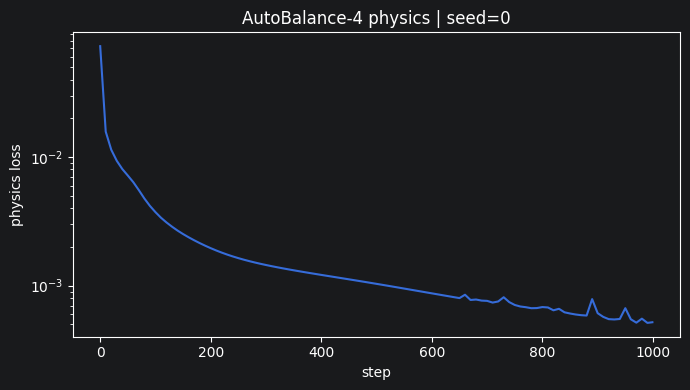

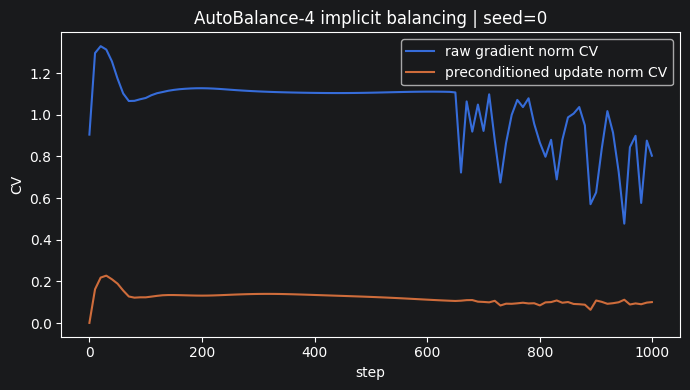

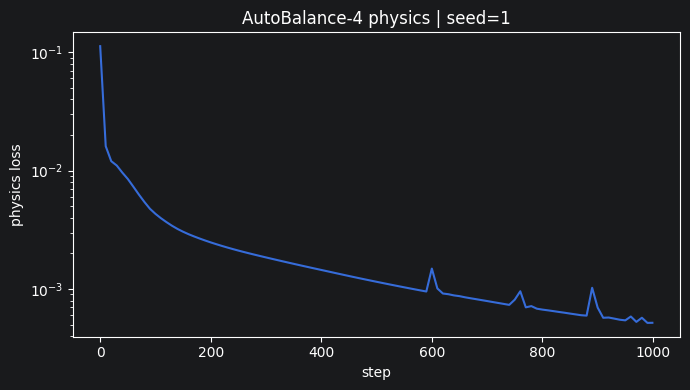

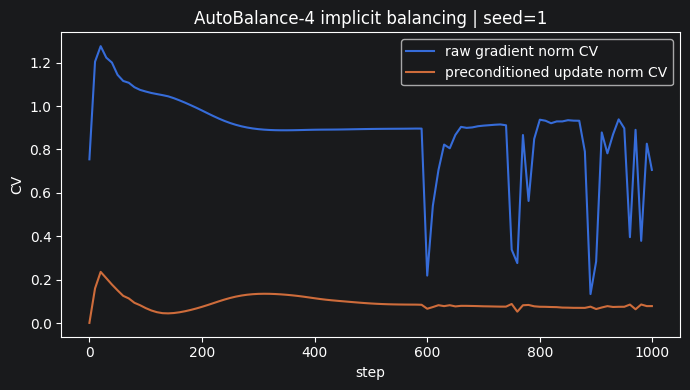

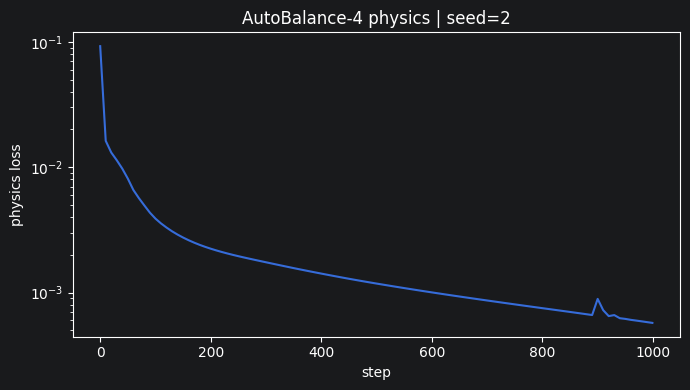

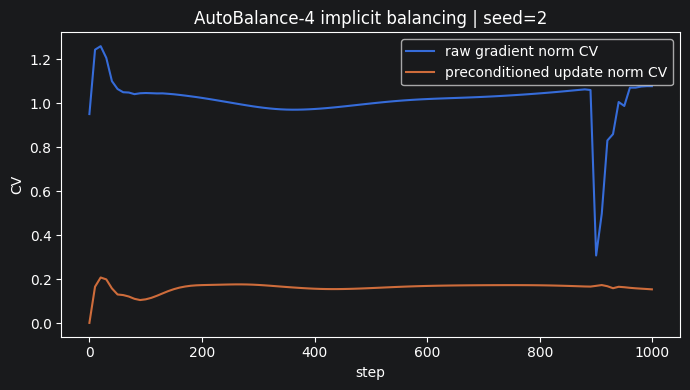

In [11]:
for seed in RUN_SEEDS:
    rs=sorted([r for r in histories if int(r['seed'])==seed],key=lambda r:int(r['step']))
    if not rs: continue
    steps=[int(r['step']) for r in rs]
    plt.figure(figsize=(7,4)); plt.semilogy(steps,[float(r['physics']) for r in rs]); plt.xlabel('step'); plt.ylabel('physics loss'); plt.title(f'AutoBalance-4 physics | seed={seed}'); plt.tight_layout(); plt.savefig(AGG/f'seed_{seed}_physics.png',dpi=220,bbox_inches='tight'); plt.show()
    plt.figure(figsize=(7,4)); plt.plot(steps,[float(r['raw_grad_norm_cv']) for r in rs],label='raw gradient norm CV'); plt.plot(steps,[float(r['precond_update_norm_cv']) for r in rs],label='preconditioned update norm CV'); plt.xlabel('step'); plt.ylabel('CV'); plt.title(f'AutoBalance-4 implicit balancing | seed={seed}'); plt.legend(); plt.tight_layout(); plt.savefig(AGG/f'seed_{seed}_norm_cv.png',dpi=220,bbox_inches='tight'); plt.show()


# 跑完后优先上传这些文件

```text
aggregate/mean_std_summary.csv
aggregate/threshold_mean_std.csv
aggregate/task_update_balance_summary.csv
aggregate/pairwise_geometry_summary.csv
aggregate/combined_direction_alignment_summary.csv
```

如需诊断训练过程，再补：

```text
aggregate/all_metric_history.csv
aggregate/all_field_metrics.csv
aggregate/all_run_meta.csv
```


In [12]:
print(OUTPUT_ROOT.resolve())
print('Expected aggregate files:')
for name in ['mean_std_summary.csv','threshold_mean_std.csv','task_update_balance_summary.csv','pairwise_geometry_summary.csv','combined_direction_alignment_summary.csv','all_metric_history.csv']:
    print(' -', name)


/home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_autobalance4
Expected aggregate files:
 - mean_std_summary.csv
 - threshold_mean_std.csv
 - task_update_balance_summary.csv
 - pairwise_geometry_summary.csv
 - combined_direction_alignment_summary.csv
 - all_metric_history.csv
